In [14]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import SystemMessage

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [15]:
# ----------------------------
# 1) Create LTM store 
# ----------------------------
store = InMemoryStore()

In [16]:
# ----------------------------
# 2) LLM that decides what to remember (structured output)
# ----------------------------
extractor_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [17]:
class MemoryDecision(BaseModel):
    should_write: bool = Field(description="Whether to store any memories")
    memories: List[str] = Field(default_factory=list, description="Atomic user memories to store")

In [18]:
memory_extractor = extractor_llm.with_structured_output(MemoryDecision)

In [19]:
# ----------------------------
# 3) Graph START -> remember -> END
#     (Creates memories, but does NOT use them to answer)
# ----------------------------

def remember_only_node(state: MessagesState, config: RunnableConfig, store:BaseStore):
    
    user_id = config["configurable"]["user_id"]
    
    namespace = ("user", user_id, "details")
    
    # take latest user message
    last_msg = state["messages"][-1].content
    
    # LLM decides what to store
    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(
                content=(
                    "Extract LONG-TERM memories from the user's message \n"
                    "Only store stable, user-specific info (identity, preferences, ongoing projects). \n"
                    "Return should_write=False if nothing is worth storing. \n"
                    "Each memory should be a short atomic sentence."
                )
            ),
            {"role": "user", "content": last_msg},
        ]
    )
    
    # write to store (LTM)
    if decision.should_write:
        for mem in decision.memories:
            store.put(namespace=namespace, key=str(uuid.uuid4()), value={"data": mem})
    
    # IMPORTANT: we are NOT using the memories to answer in this graph, so we just return the original message
    return {"messages": [{"role": "assistant", "content": "Noted."}]}

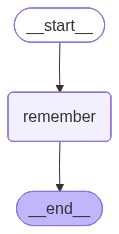

In [20]:
builder = StateGraph(MessagesState)
builder.add_node("remember", remember_only_node)
builder.add_edge(START, "remember")
builder.add_edge("remember", END)

graph = builder.compile(store=store)

graph

In [23]:
# ----------------------------
# 4) Demo
# ----------------------------
config = {"configurable": {"user_id": "u1"}}

res = graph.invoke({"messages": [{"role": "user", "content": "Hi my name is Sanjog"}]}, config)
print("Assistant:", res["messages"][-1].content)

Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://smith.langchain.com/runs/multipart in LangSmith API. HTTPError('405 Client Error: Method Not Allowed for url: https://smith.langchain.com/runs/multipart', '<html>\r\n<head><title>405 Not Allowed</title></head>\r\n<body>\r\n<center><h1>405 Not Allowed</h1></center>\r\n<hr><center>nginx</center>\r\n</body>\r\n</html>\r\n')


Assistant: Noted.


Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://smith.langchain.com/runs/multipart in LangSmith API. HTTPError('405 Client Error: Method Not Allowed for url: https://smith.langchain.com/runs/multipart', '<html>\r\n<head><title>405 Not Allowed</title></head>\r\n<body>\r\n<center><h1>405 Not Allowed</h1></center>\r\n<hr><center>nginx</center>\r\n</body>\r\n</html>\r\n')


In [24]:
res = graph.invoke({"messages": [{"role": "user", "content": "I teach AI on youtube"}]}, config)
print("Assistant:", res["messages"][-1].content)

Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://smith.langchain.com/runs/multipart in LangSmith API. HTTPError('405 Client Error: Method Not Allowed for url: https://smith.langchain.com/runs/multipart', '<html>\r\n<head><title>405 Not Allowed</title></head>\r\n<body>\r\n<center><h1>405 Not Allowed</h1></center>\r\n<hr><center>nginx</center>\r\n</body>\r\n</html>\r\n')


Assistant: Noted.


Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://smith.langchain.com/runs/multipart in LangSmith API. HTTPError('405 Client Error: Method Not Allowed for url: https://smith.langchain.com/runs/multipart', '<html>\r\n<head><title>405 Not Allowed</title></head>\r\n<body>\r\n<center><h1>405 Not Allowed</h1></center>\r\n<hr><center>nginx</center>\r\n</body>\r\n</html>\r\n')


In [ ]:
res = graph.invoke({"messages": [{"role": "user", "content": "My favorite programming language is Python"}]}, config)
print("Assistant:", res["messages"][-1].content)

Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://smith.langchain.com/runs/multipart in LangSmith API. HTTPError('405 Client Error: Method Not Allowed for url: https://smith.langchain.com/runs/multipart', '<html>\r\n<head><title>405 Not Allowed</title></head>\r\n<body>\r\n<center><h1>405 Not Allowed</h1></center>\r\n<hr><center>nginx</center>\r\n</body>\r\n</html>\r\n')


Assistant: Noted.


Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://smith.langchain.com/runs/multipart in LangSmith API. HTTPError('405 Client Error: Method Not Allowed for url: https://smith.langchain.com/runs/multipart', '<html>\r\n<head><title>405 Not Allowed</title></head>\r\n<body>\r\n<center><h1>405 Not Allowed</h1></center>\r\n<hr><center>nginx</center>\r\n</body>\r\n</html>\r\n')


In [26]:
items = store.search(("user", "u1", "details"))

for item in items:
    print(item.value["data"])

User's name is Sanjog.
User's name is Sanjog.
User teaches AI on YouTube.
User's favorite programming language is Python.


In [ ]:
# The biggest flaw in this is it will store duplicate memories also
